#Chat Metrics

##Data Collection

In [1]:
import pandas            as pd
import numpy             as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import (
  accuracy_score,
  precision_score,
  recall_score,
  f1_score,
  roc_auc_score,
  classification_report
)

df = pd.read_parquet('https://huggingface.co/datasets/ddds-Capstone/Datasets/resolve/main/chat_metrics.parquet')

##XGBoost

In [2]:
features = [
  'output_tokens',
  'month_sin',
  'model_calls',
  'primary_category_navigation',
  'answer_sentiment',
  'question_length',
  'hour_sin',
  'total_tokens',
  'primary_category_sunport_amenities',
  'day_sin'
]

X = df[features]
y = df['satisfaction']

X_train, X_test, y_train, y_test = train_test_split(
  X,
  y,
  test_size=0.20,
  random_state=42,
  stratify=y #Maintains roughly same proportion
)

#Final XGBoost model
xgb = XGBClassifier(
  n_estimators=300,   #Boosting rounds/trees
  learning_rate=0.01, #Controls how much each new tree contributest to model
  max_depth=8,        #Max deptho or each tree
  random_state=42,
  objective = 'binary:logistic', # Tells XGBoost to do binary classification
  eval_metric='logloss'
)

#Fit
xgb.fit(X_train, y_train)

#Predict
y_pred_xgb = xgb.predict(X_test)

#Probability
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print('Accuracy:', accuracy_score(y_test, y_pred_xgb))
print('Precision:', precision_score(y_test, y_pred_xgb))
print('Recall:', recall_score(y_test, y_pred_xgb))
print('F1:', f1_score(y_test, y_pred_xgb))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_xgb))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.7471264367816092
Precision: 0.75
Recall: 0.782608695652174
F1: 0.7659574468085106
ROC-AUC: 0.8128313891834571

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.71      0.72        41
           1       0.75      0.78      0.77        46

    accuracy                           0.75        87
   macro avg       0.75      0.74      0.75        87
weighted avg       0.75      0.75      0.75        87



##Simulation Chatbot

###Answer Sentiment

In [3]:
baseline_prob = xgb.predict_proba(X_test)[:, 1].mean()

sentiment_results = []

for sentiment in sorted(X_test['answer_sentiment'].unique()):

  X_sim = X_test.copy()
  X_sim['answer_sentiment'] = sentiment

  probability = xgb.predict_proba(X_sim)[:, 1].mean()
  change = probability - baseline_prob

  sentiment_results.append({
    'Answer Sentiment': sentiment,
    'Predicted Satisfaction': probability,
    'Change from Baseline': change
  })

sentiment_results = pd.DataFrame(sentiment_results)
sentiment_results

,Answer Sentiment,Predicted Satisfaction,Change from Baseline
0,-0.5267,0.395092,-0.155019
1,-0.2640,0.395092,-0.155019
2,0.0000,0.495767,-0.054345
3,0.0258,0.476315,-0.073796
4,0.0772,0.484251,-0.065861
...,...,...,...
57,0.9703,0.540197,-0.009914
58,0.9834,0.540005,-0.010107
59,0.9855,0.540005,-0.010107
60,0.9886,0.540005,-0.010107


###Output Tokens

In [4]:
baseline_prob = xgb.predict_proba(X_test)[:, 1].mean()

token_results = []

token_values = [800, 1000, 1200, 1500, 1800]

for tokens in token_values:

  X_sim = X_test.copy()
  X_sim['output_tokens'] = tokens

  probability = xgb.predict_proba(X_sim)[:, 1].mean()
  change = probability - baseline_prob

  token_results.append({
    'Output Tokens': tokens,
    'Predicted Satisfaction': probability,
    'Change from Baseline': change
  })

token_results = pd.DataFrame(token_results)
token_results

,Output Tokens,Predicted Satisfaction,Change from Baseline
0,800,0.749161,0.199049
1,1000,0.749161,0.199049
2,1200,0.742931,0.192819
3,1500,0.682843,0.132732
4,1800,0.687543,0.137432


###Model Calls

In [5]:
baseline_prob = xgb.predict_proba(X_test)[:, 1].mean()

model_call_results = []

model_call_values = [4, 6, 8, 10, 12, 14]

for calls in model_call_values:

  X_sim = X_test.copy()
  X_sim['model_calls'] = calls

  probability = xgb.predict_proba(X_sim)[:, 1].mean()
  change = probability - baseline_prob

  model_call_results.append({
    'Model Calls': calls,
    'Predicted Satisfaction': probability,
    'Change from Baseline': change
  })

model_call_results = pd.DataFrame(model_call_results)
model_call_results

,Model Calls,Predicted Satisfaction,Change from Baseline
0,4,0.559779,0.009668
1,6,0.580142,0.030031
2,8,0.538806,-0.011305
3,10,0.379447,-0.170664
4,12,0.379447,-0.170664
5,14,0.379878,-0.170233


##Data Visualization

###Answer Sentiment

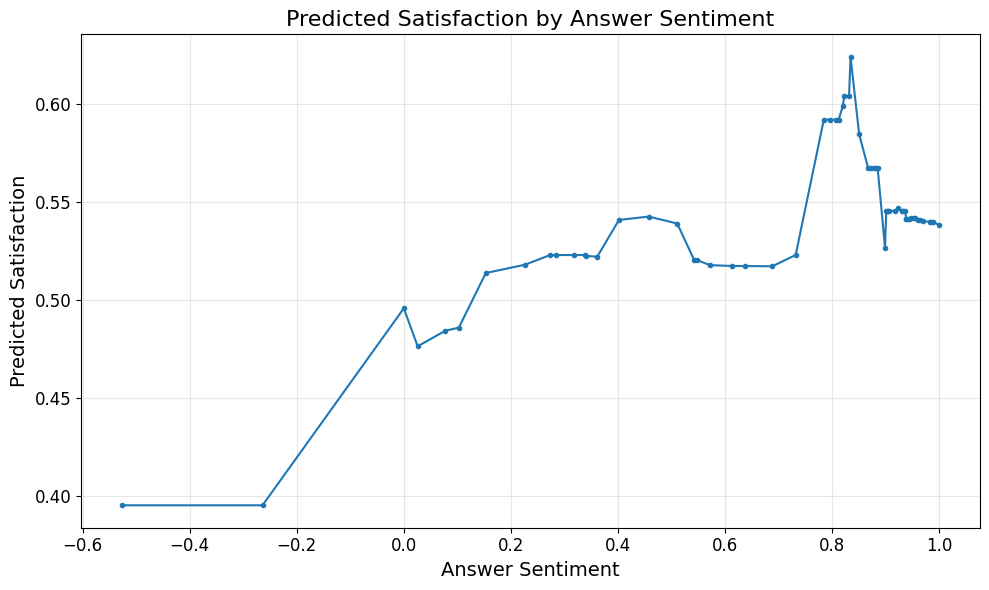

In [7]:
plt.figure(figsize=(10, 6))

plt.plot(
    sentiment_results['Answer Sentiment'],
    sentiment_results['Predicted Satisfaction'],
    marker='o',
    markersize=3
)

plt.xlabel('Answer Sentiment', fontsize=14)
plt.ylabel('Predicted Satisfaction', fontsize=14)
plt.title('Predicted Satisfaction by Answer Sentiment', fontsize=16)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(alpha=0.3) #Shows grid in background

plt.tight_layout()
plt.savefig('sentiment_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

###Output Tokens

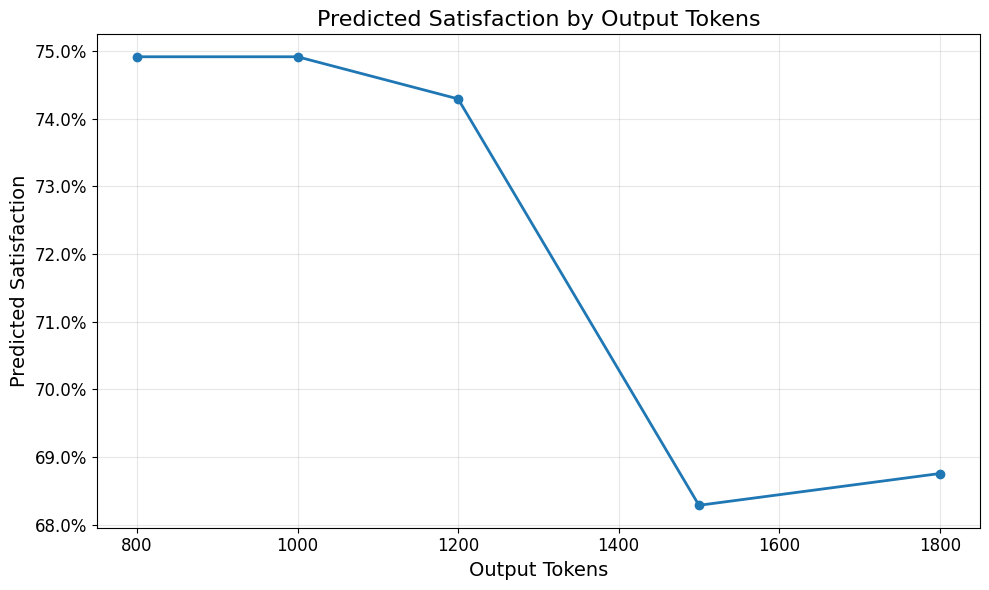

In [8]:
plt.figure(figsize=(10, 6))

plt.plot(
    token_results['Output Tokens'],
    token_results['Predicted Satisfaction'],
    marker='o',
    linewidth=2
)

plt.xlabel('Output Tokens', fontsize=14)
plt.ylabel('Predicted Satisfaction', fontsize=14)
plt.title('Predicted Satisfaction by Output Tokens', fontsize=16)

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('output_tokens_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

###Model Calls

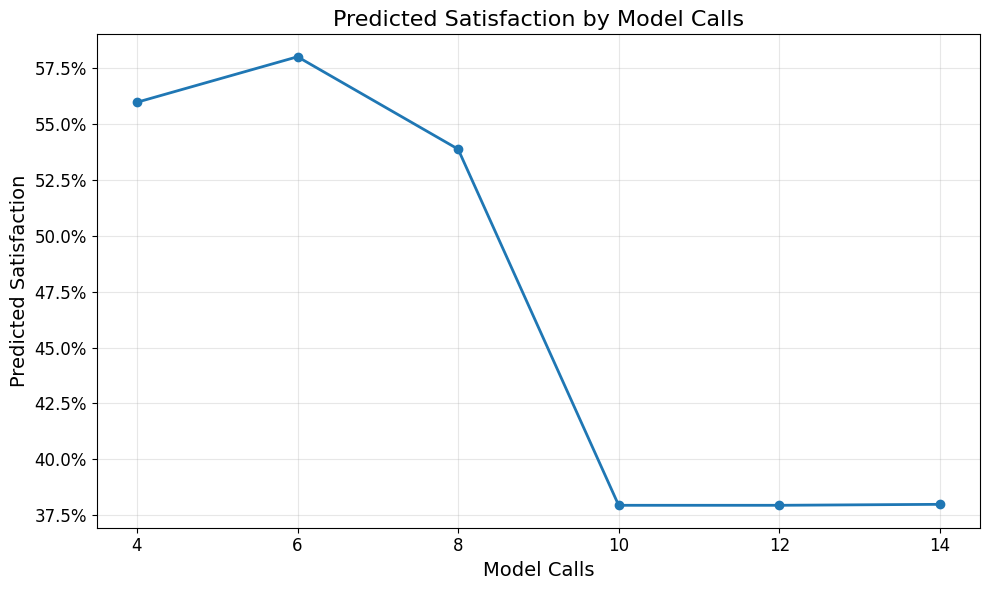

In [9]:
plt.figure(figsize=(10, 6))

plt.plot(
    model_call_results['Model Calls'],
    model_call_results['Predicted Satisfaction'],
    marker='o',
    linewidth=2
)

plt.xlabel('Model Calls', fontsize=14)
plt.ylabel('Predicted Satisfaction', fontsize=14)
plt.title('Predicted Satisfaction by Model Calls', fontsize=16)

# Format y-axis as percentages
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Make tick labels larger
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()

# Save for presentation
plt.savefig(
    'model_calls_optimization.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()